# 🔬 Quantum Filter + EKF Analysis

Analyzes the **hybrid QF+EKF** rosbag to compare three stages:
1. **Raw** sensor data (before quantum filtering)
2. **QF-Filtered** sensor data (after QPSO wavelet denoising)
3. **EKF-Fused** output (after QF-based EKF fusion)

### Recording command
```bash
source /home/anish/Multi-sensor-fusion/install/setup.bash
ros2 bag record -o /home/rosdata/hybrid_qf_ekf_$(date +%Y%m%d_%H%M%S) \
  /clock /imu/data /imu/data/filtered \
  /gps/fix /gps/fix/filtered /gps/filtered \
  /diff_drive_controller/odom /diff_drive_controller/odom/filtered \
  /odometry/local /odometry/global /odometry/gps \
  /cmd_vel /tf /tf_static /joint_states
```
Set `BAG_PATH` below to the rosbag **folder** and run all cells.

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURE: Set your hybrid QF+EKF bag FOLDER here          ║
# ╚══════════════════════════════════════════════════════════════╝

BAG_PATH = '/home/rosdata/hybrid_qf_ekf_tuned'  # <-- CHANGE THIS

In [2]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

typestore = get_typestore(Stores.ROS2_HUMBLE)

# ── Helpers ──
def npcol(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def npxy(df, xcol='x', ycol='y'):
    x, y = npcol(df, xcol), npcol(df, ycol)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

# ── Dark theme ──
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#444444',
    'font.size': 11,
})

COLORS = {
    'raw':        '#ff6b6b',
    'filtered':   '#51cf66',
    'ekf_local':  '#339af0',
    'ekf_global': '#ffd43b',
    'gps':        '#ff922b',
}

PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

print('Imports OK ✓')
print(f'Bag path: {BAG_PATH}')
print(f'Bag exists: {Path(BAG_PATH).exists()}')

Imports OK ✓
Bag path: /home/rosdata/hybrid_qf_ekf_tuned
Bag exists: True


## 1. Extract Data from Rosbag

In [3]:
def extract_hybrid_bag(bag_path):
    """Extract raw, filtered, and EKF data from a hybrid QF+EKF rosbag."""
    data = {
        # Raw sensors
        'imu_raw': [], 'gps_raw': [], 'odom_raw': [], 'vo_raw': [], 'lo_raw': [],
        # QF-filtered sensors
        'imu_filt': [], 'gps_filt': [], 'odom_filt': [], 'vo_filt': [], 'lo_filt': [],
        # EKF outputs
        'ekf_local': [], 'ekf_global': [], 'gps_odom': [],
    }

    topic_map = {
        '/imu/data':                          'imu_raw',
        '/imu/data/filtered':                 'imu_filt',
        '/gps/fix':                           'gps_raw',
        '/gps/fix/filtered':                  'gps_filt',
        '/diff_drive_controller/odom':        'odom_raw',
        '/diff_drive_controller/odom/filtered': 'odom_filt',
        '/odometry/visual': 'vo_raw',
        '/odometry/visual/filtered': 'vo_filt',
        '/odometry/lidar': 'lo_raw',
        '/odometry/lidar/filtered': 'lo_filt',
        '/odometry/local':                    'ekf_local',
        '/odometry/global':                   'ekf_global',
        '/odometry/gps':                      'gps_odom',
    }

    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        print(f'Reading bag: {bag_path}')
        avail = set(reader.topics.keys())
        print(f'Topics found: {sorted(avail)}')
        needed = set(topic_map.keys())
        missing = needed - avail
        if missing:
            print(f'⚠ Missing topics: {missing}')

        for connection, timestamp, rawdata in reader.messages():
            topic = connection.topic
            if topic not in topic_map:
                continue

            key = topic_map[topic]
            msg = reader.deserialize(rawdata, connection.msgtype)
            t_sec = timestamp * 1e-9

            if key.startswith('imu'):
                data[key].append({
                    't': t_sec,
                    'ax': msg.linear_acceleration.x,
                    'ay': msg.linear_acceleration.y,
                    'az': msg.linear_acceleration.z,
                    'gx': msg.angular_velocity.x,
                    'gy': msg.angular_velocity.y,
                    'gz': msg.angular_velocity.z,
                    'yaw': quat_to_yaw(msg.orientation),
                })
            elif key.startswith('gps'):
                if key == 'gps_odom':  # Odometry msg
                    data[key].append({
                        't': t_sec,
                        'x': msg.pose.pose.position.x,
                        'y': msg.pose.pose.position.y,
                    })
                else:  # NavSatFix msg
                    data[key].append({
                        't': t_sec,
                        'lat': msg.latitude,
                        'lon': msg.longitude,
                        'alt': msg.altitude,
                    })
            elif key.startswith('odom') or key.startswith('vo') or key.startswith('lo') or key.startswith('ekf'):
                data[key].append({
                    't': t_sec,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                    'vx': msg.twist.twist.linear.x,
                    'vyaw': msg.twist.twist.angular.z,
                    'yaw': quat_to_yaw(msg.pose.pose.orientation),
                })

    # Convert to DataFrames
    dfs = {}
    t0 = float('inf')
    for key, rows in data.items():
        if rows:
            df = pd.DataFrame(rows)
            t0 = min(t0, df['t'].iloc[0])
            dfs[key] = df
    for key in dfs:
        dfs[key]['t'] -= t0

    # Summary table
    print('\n' + '=' * 65)
    print(f'{"Source":>20s}  {"Messages":>8s}  {"Duration":>8s}  {"Rate":>7s}')
    print('=' * 65)
    for name, df in dfs.items():
        dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
        hz = len(df) / dur if dur > 0 else 0
        print(f'{name:>20s}  {len(df):8d}  {dur:7.1f}s  {hz:6.1f} Hz')
    print('=' * 65)
    return dfs

dfs = extract_hybrid_bag(BAG_PATH)

Reading bag: /home/rosdata/hybrid_qf_ekf_tuned
Topics found: ['/clock', '/cmd_vel', '/diff_drive_controller/odom', '/diff_drive_controller/odom/filtered', '/gps/filtered', '/gps/fix', '/gps/fix/filtered', '/imu/data', '/imu/data/filtered', '/joint_states', '/odometry/global', '/odometry/gps', '/odometry/lidar', '/odometry/lidar/filtered', '/odometry/local', '/odometry/visual', '/odometry/visual/filtered', '/tf', '/tf_static']



              Source  Messages  Duration     Rate
             imu_raw     12864     67.5s   190.5 Hz
             gps_raw       644     67.5s     9.5 Hz
            odom_raw      3215     67.5s    47.6 Hz
              vo_raw       878     67.4s    13.0 Hz
              lo_raw       321     67.2s     4.8 Hz
            imu_filt       819     67.5s    12.1 Hz
            gps_filt       643     67.4s     9.5 Hz
           odom_filt       818     67.4s    12.1 Hz
             vo_filt       811     67.4s    12.0 Hz
             lo_filt       322     67.4s     4.8 Hz
           ekf_local       739     67.4s    11.0 Hz
          ekf_global       751     67.4s    11.1 Hz
            gps_odom       527     67.4s     7.8 Hz


## 2. IMU: Raw vs Quantum-Filtered

Compare raw and QF-denoised IMU accelerometer and gyroscope signals.

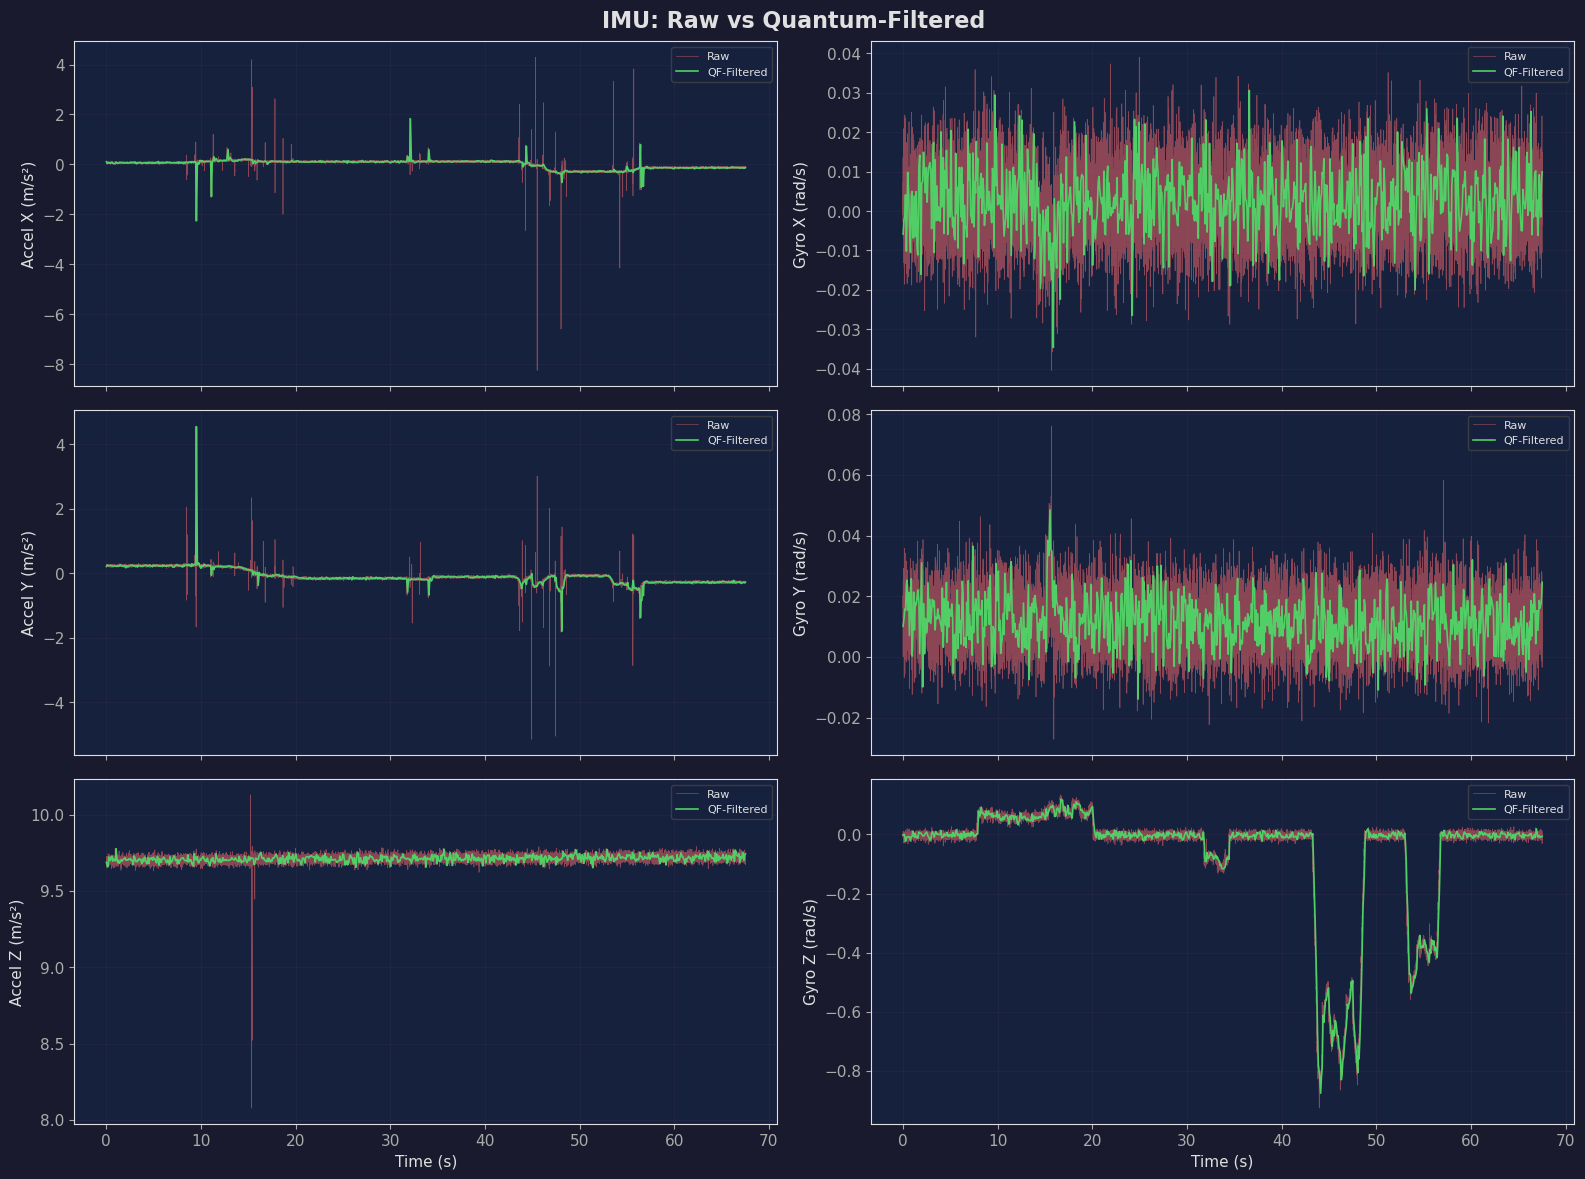

Saved: plots/qf_imu_comparison.png

── IMU Noise Reduction ──
   Channel       Raw σ      Filt σ   Reduction
        ax    0.225845    0.203506        9.9%
        ay    0.233830    0.267002      -14.2%
        az    0.028779    0.019263       33.1%
        gx    0.009172    0.008241       10.2%
        gy    0.009255    0.008148       12.0%
        gz    0.197677    0.198512       -0.4%


In [4]:
if 'imu_raw' in dfs and 'imu_filt' in dfs:
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    fig.suptitle('IMU: Raw vs Quantum-Filtered', fontsize=16, fontweight='bold')

    raw = dfs['imu_raw']
    filt = dfs['imu_filt']

    channels = [
        ('ax', 'Accel X (m/s²)'),  ('gx', 'Gyro X (rad/s)'),
        ('ay', 'Accel Y (m/s²)'),  ('gy', 'Gyro Y (rad/s)'),
        ('az', 'Accel Z (m/s²)'),  ('gz', 'Gyro Z (rad/s)'),
    ]

    for idx, (ch, label) in enumerate(channels):
        row, col = idx // 2, idx % 2
        ax = axes[row, col]
        ax.plot(npcol(raw, 't'), npcol(raw, ch),
                color=COLORS['raw'], alpha=0.5, lw=0.5, label='Raw')
        ax.plot(npcol(filt, 't'), npcol(filt, ch),
                color=COLORS['filtered'], lw=1.2, label='QF-Filtered')
        ax.set_ylabel(label)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True)

    axes[2, 0].set_xlabel('Time (s)')
    axes[2, 1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_imu_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_imu_comparison.png')

    # Noise reduction stats
    print('\n── IMU Noise Reduction ──')
    print(f'{"Channel":>10s}  {"Raw σ":>10s}  {"Filt σ":>10s}  {"Reduction":>10s}')
    for ch in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        r_std = np.nanstd(npcol(raw, ch))
        f_std = np.nanstd(npcol(filt, ch))
        pct = (1 - f_std / r_std) * 100 if r_std > 0 else 0
        print(f'{ch:>10s}  {r_std:10.6f}  {f_std:10.6f}  {pct:9.1f}%')
else:
    print('⚠ IMU raw/filtered data not found in bag')

## 3. GPS: Raw vs Quantum-Filtered

Compare raw and QF-denoised GPS lat/lon signals.

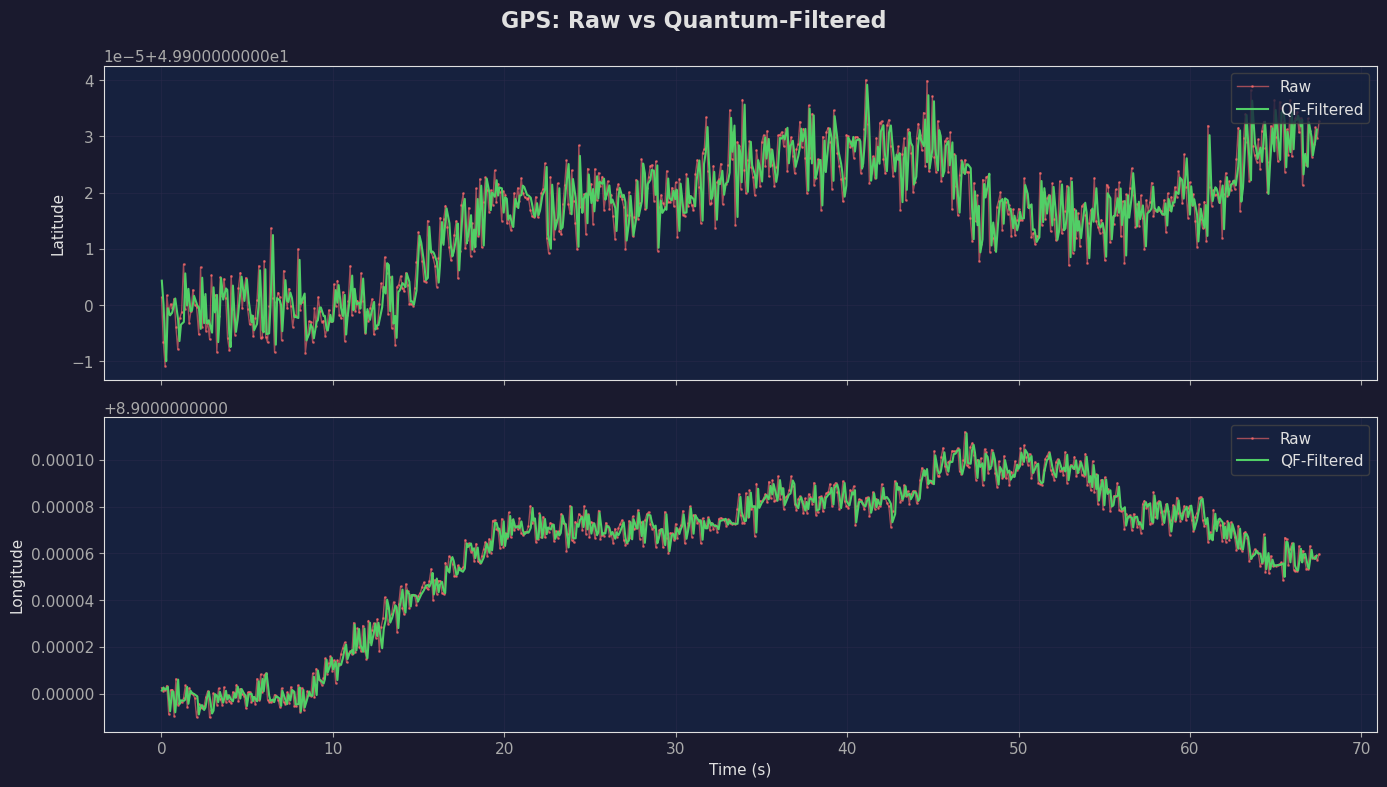

Saved: plots/qf_gps_comparison.png


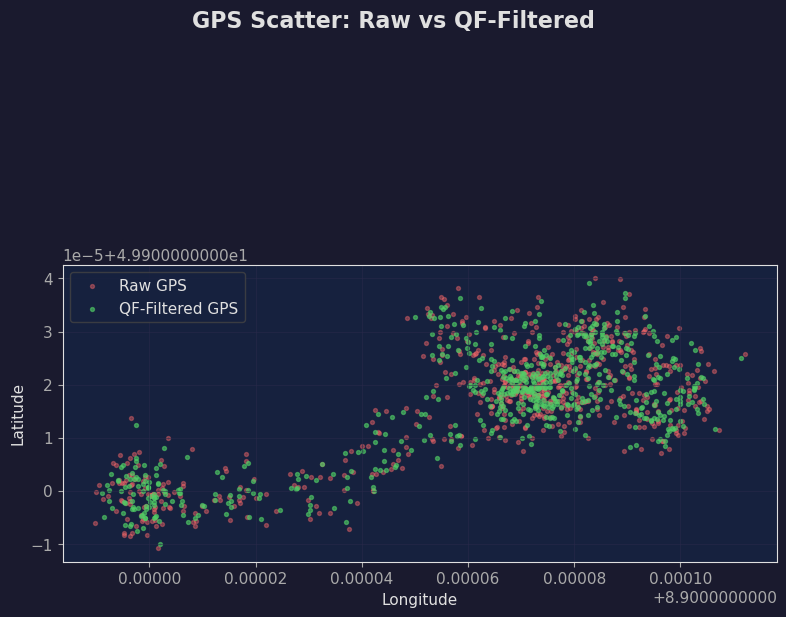

Saved: plots/qf_gps_scatter.png


In [5]:
if 'gps_raw' in dfs and 'gps_filt' in dfs:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('GPS: Raw vs Quantum-Filtered', fontsize=16, fontweight='bold')

    raw = dfs['gps_raw']
    filt = dfs['gps_filt']

    for idx, (ch, label) in enumerate([('lat', 'Latitude'), ('lon', 'Longitude')]):
        ax = axes[idx]
        ax.plot(npcol(raw, 't'), npcol(raw, ch),
                color=COLORS['raw'], alpha=0.6, lw=1, label='Raw', marker='.', ms=2)
        ax.plot(npcol(filt, 't'), npcol(filt, ch),
                color=COLORS['filtered'], lw=1.5, label='QF-Filtered')
        ax.set_ylabel(label)
        ax.legend(loc='upper right')
        ax.grid(True)

    axes[1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_gps_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_gps_comparison.png')

    # GPS scatter: raw vs filtered
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.suptitle('GPS Scatter: Raw vs QF-Filtered', fontsize=16, fontweight='bold')
    ax.scatter(npcol(raw, 'lon'), npcol(raw, 'lat'),
               s=8, alpha=0.4, color=COLORS['raw'], label='Raw GPS')
    ax.scatter(npcol(filt, 'lon'), npcol(filt, 'lat'),
               s=8, alpha=0.6, color=COLORS['filtered'], label='QF-Filtered GPS')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_gps_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_gps_scatter.png')
else:
    print('⚠ GPS raw/filtered data not found in bag')

## 4. Wheel Odometry: Raw vs Quantum-Filtered

Compare raw and QF-denoised velocity signals from the diff_drive_controller.

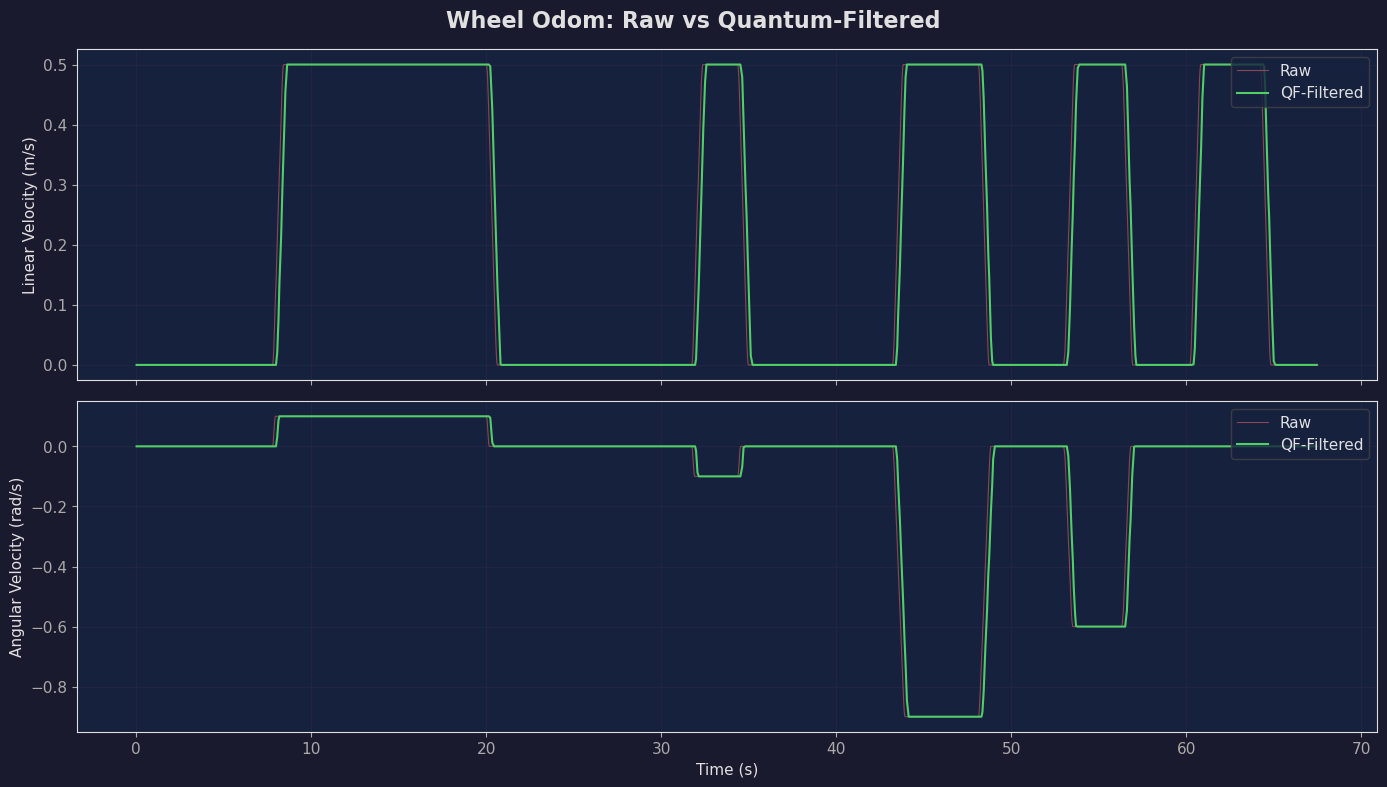

Saved: plots/qf_odom_comparison.png


In [6]:
if 'odom_raw' in dfs and 'odom_filt' in dfs:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('Wheel Odom: Raw vs Quantum-Filtered', fontsize=16, fontweight='bold')

    raw = dfs['odom_raw']
    filt = dfs['odom_filt']

    for idx, (ch, label) in enumerate([('vx', 'Linear Velocity (m/s)'), ('vyaw', 'Angular Velocity (rad/s)')]):
        ax = axes[idx]
        ax.plot(npcol(raw, 't'), npcol(raw, ch),
                color=COLORS['raw'], alpha=0.5, lw=0.8, label='Raw')
        ax.plot(npcol(filt, 't'), npcol(filt, ch),
                color=COLORS['filtered'], lw=1.5, label='QF-Filtered')
        ax.set_ylabel(label)
        ax.legend(loc='upper right')
        ax.grid(True)

    axes[1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_odom_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_odom_comparison.png')
else:
    print('⚠ Odom raw/filtered data not found in bag')

## 4a. Visual Odometry: Raw vs Quantum-Filtered

Compare raw and QF-denoised velocity signals from the visual odometry.

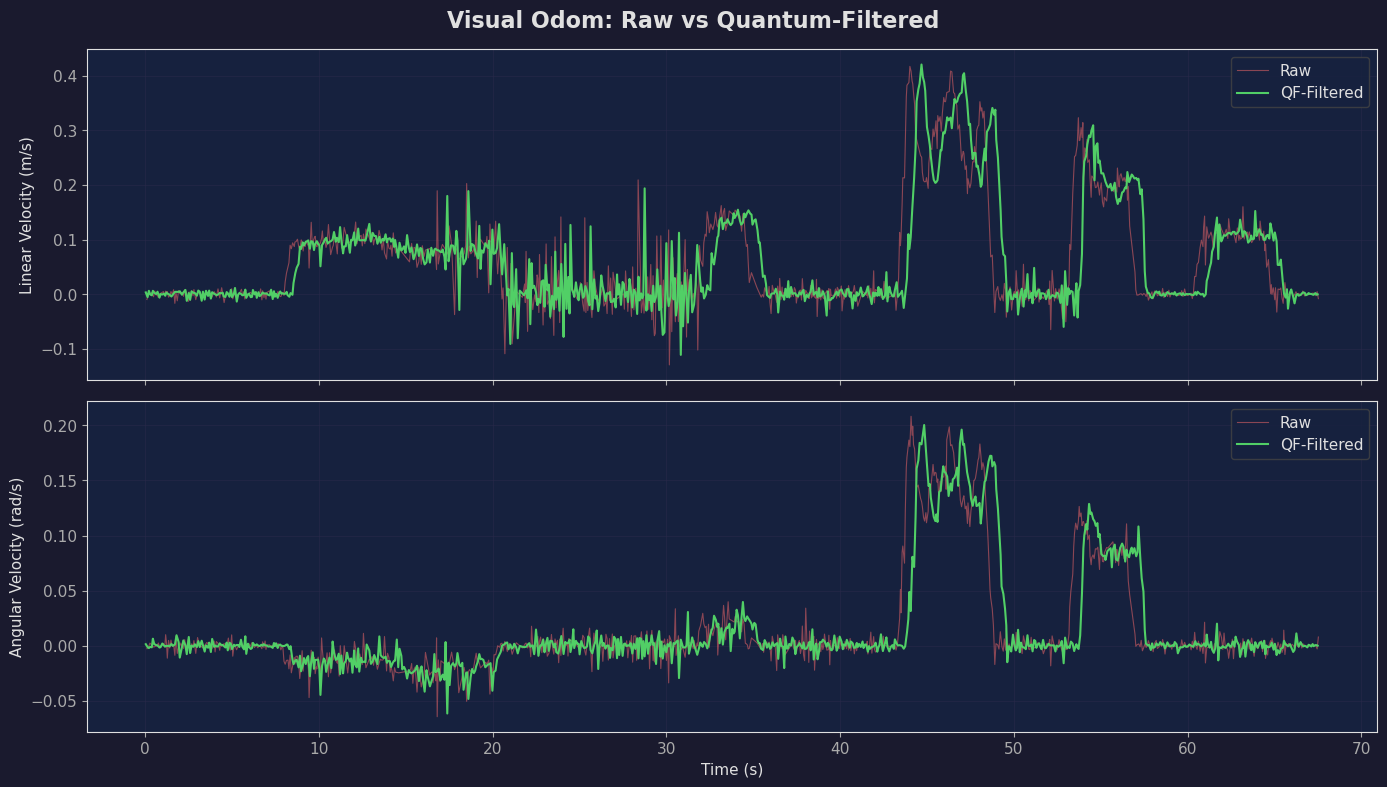

Saved: plots/qf_vo_comparison.png


In [7]:
if 'vo_raw' in dfs and 'vo_filt' in dfs:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('Visual Odom: Raw vs Quantum-Filtered', fontsize=16, fontweight='bold')

    raw = dfs['vo_raw']
    filt = dfs['vo_filt']

    for idx, (ch, label) in enumerate([('vx', 'Linear Velocity (m/s)'), ('vyaw', 'Angular Velocity (rad/s)')]):
        ax = axes[idx]
        ax.plot(npcol(raw, 't'), npcol(raw, ch),
                color=COLORS['raw'], alpha=0.5, lw=0.8, label='Raw')
        ax.plot(npcol(filt, 't'), npcol(filt, ch),
                color=COLORS['filtered'], lw=1.5, label='QF-Filtered')
        ax.set_ylabel(label)
        ax.legend(loc='upper right')
        ax.grid(True)

    axes[1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_vo_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_vo_comparison.png')
else:
    print('⚠ Visual Odom raw/filtered data not found in bag')

## 4b. LiDAR Odometry: Raw vs Quantum-Filtered

Compare raw and QF-denoised velocity signals from the LiDAR odometry.

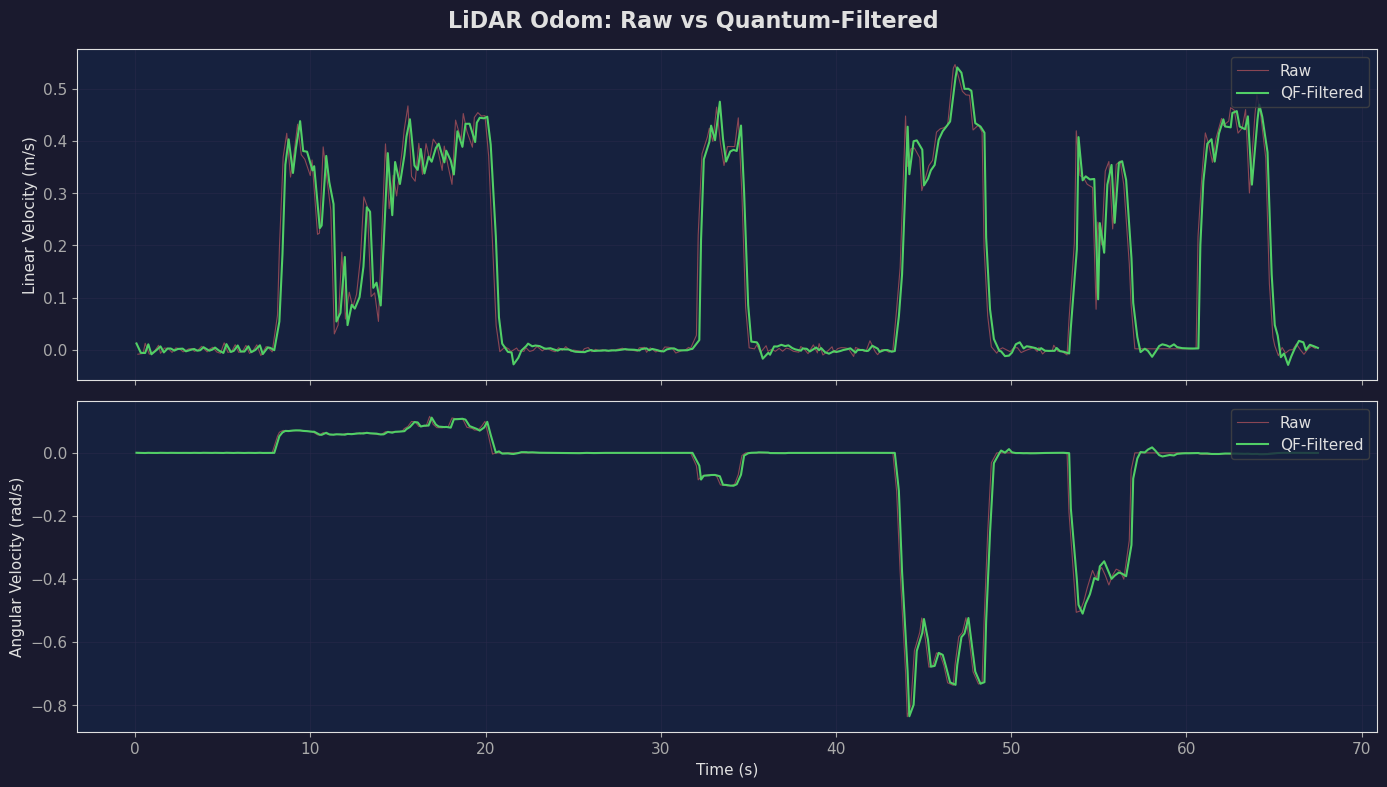

Saved: plots/qf_lo_comparison.png


In [8]:
if 'lo_raw' in dfs and 'lo_filt' in dfs:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('LiDAR Odom: Raw vs Quantum-Filtered', fontsize=16, fontweight='bold')

    raw = dfs['lo_raw']
    filt = dfs['lo_filt']

    for idx, (ch, label) in enumerate([('vx', 'Linear Velocity (m/s)'), ('vyaw', 'Angular Velocity (rad/s)')]):
        ax = axes[idx]
        ax.plot(npcol(raw, 't'), npcol(raw, ch),
                color=COLORS['raw'], alpha=0.5, lw=0.8, label='Raw')
        ax.plot(npcol(filt, 't'), npcol(filt, ch),
                color=COLORS['filtered'], lw=1.5, label='QF-Filtered')
        ax.set_ylabel(label)
        ax.legend(loc='upper right')
        ax.grid(True)

    axes[1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_lo_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_lo_comparison.png')
else:
    print('⚠ LiDAR Odom raw/filtered data not found in bag')

## 4c. Sensor Noise Distribution Analytics

Mathematical analysis of the noise distribution before (Raw) and after (Filtered) applying the Quantum Filter. Here, we plot the error/noise distribution histograms and kernel density/normal distribution fits to visualize how the QF algorithm reshaped and tightened the distributions.

Sensor       | Raw Var      | Filt Var     | Raw Std      | Filt Std     | % Red.  
----------------------------------------------------------------------------------
IMU ax       | 0.051006     | 0.041415     | 0.225845     | 0.203506     | 9.89    %
IMU ay       | 0.054676     | 0.071290     | 0.233830     | 0.267002     | -14.19  %
IMU az       | 0.000828     | 0.000371     | 0.028779     | 0.019263     | 33.06   %
IMU gx       | 0.000084     | 0.000068     | 0.009172     | 0.008241     | 10.16   %
IMU gy       | 0.000086     | 0.000066     | 0.009255     | 0.008148     | 11.96   %


IMU gz       | 0.039076     | 0.039407     | 0.197677     | 0.198512     | -0.42   %
GPS lat      | 0.000000     | 0.000000     | 0.000011     | 0.000011     | 2.26    %
GPS lon      | 0.000000     | 0.000000     | 0.000032     | 0.000032     | -0.16   %
Odom vx      | 0.056807     | 0.056612     | 0.238343     | 0.237934     | 0.17    %
Odom vyaw    | 0.069380     | 0.070520     | 0.263401     | 0.265557     | -0.82   %
VO vx        | 0.009758     | 0.009012     | 0.098783     | 0.094930     | 3.90    %
VO vyaw      | 0.002338     | 0.002136     | 0.048358     | 0.046218     | 4.43    %
LO vx        | 0.033306     | 0.032855     | 0.182499     | 0.181260     | 0.68    %
LO vyaw      | 0.037990     | 0.037791     | 0.194911     | 0.194399     | 0.26    %


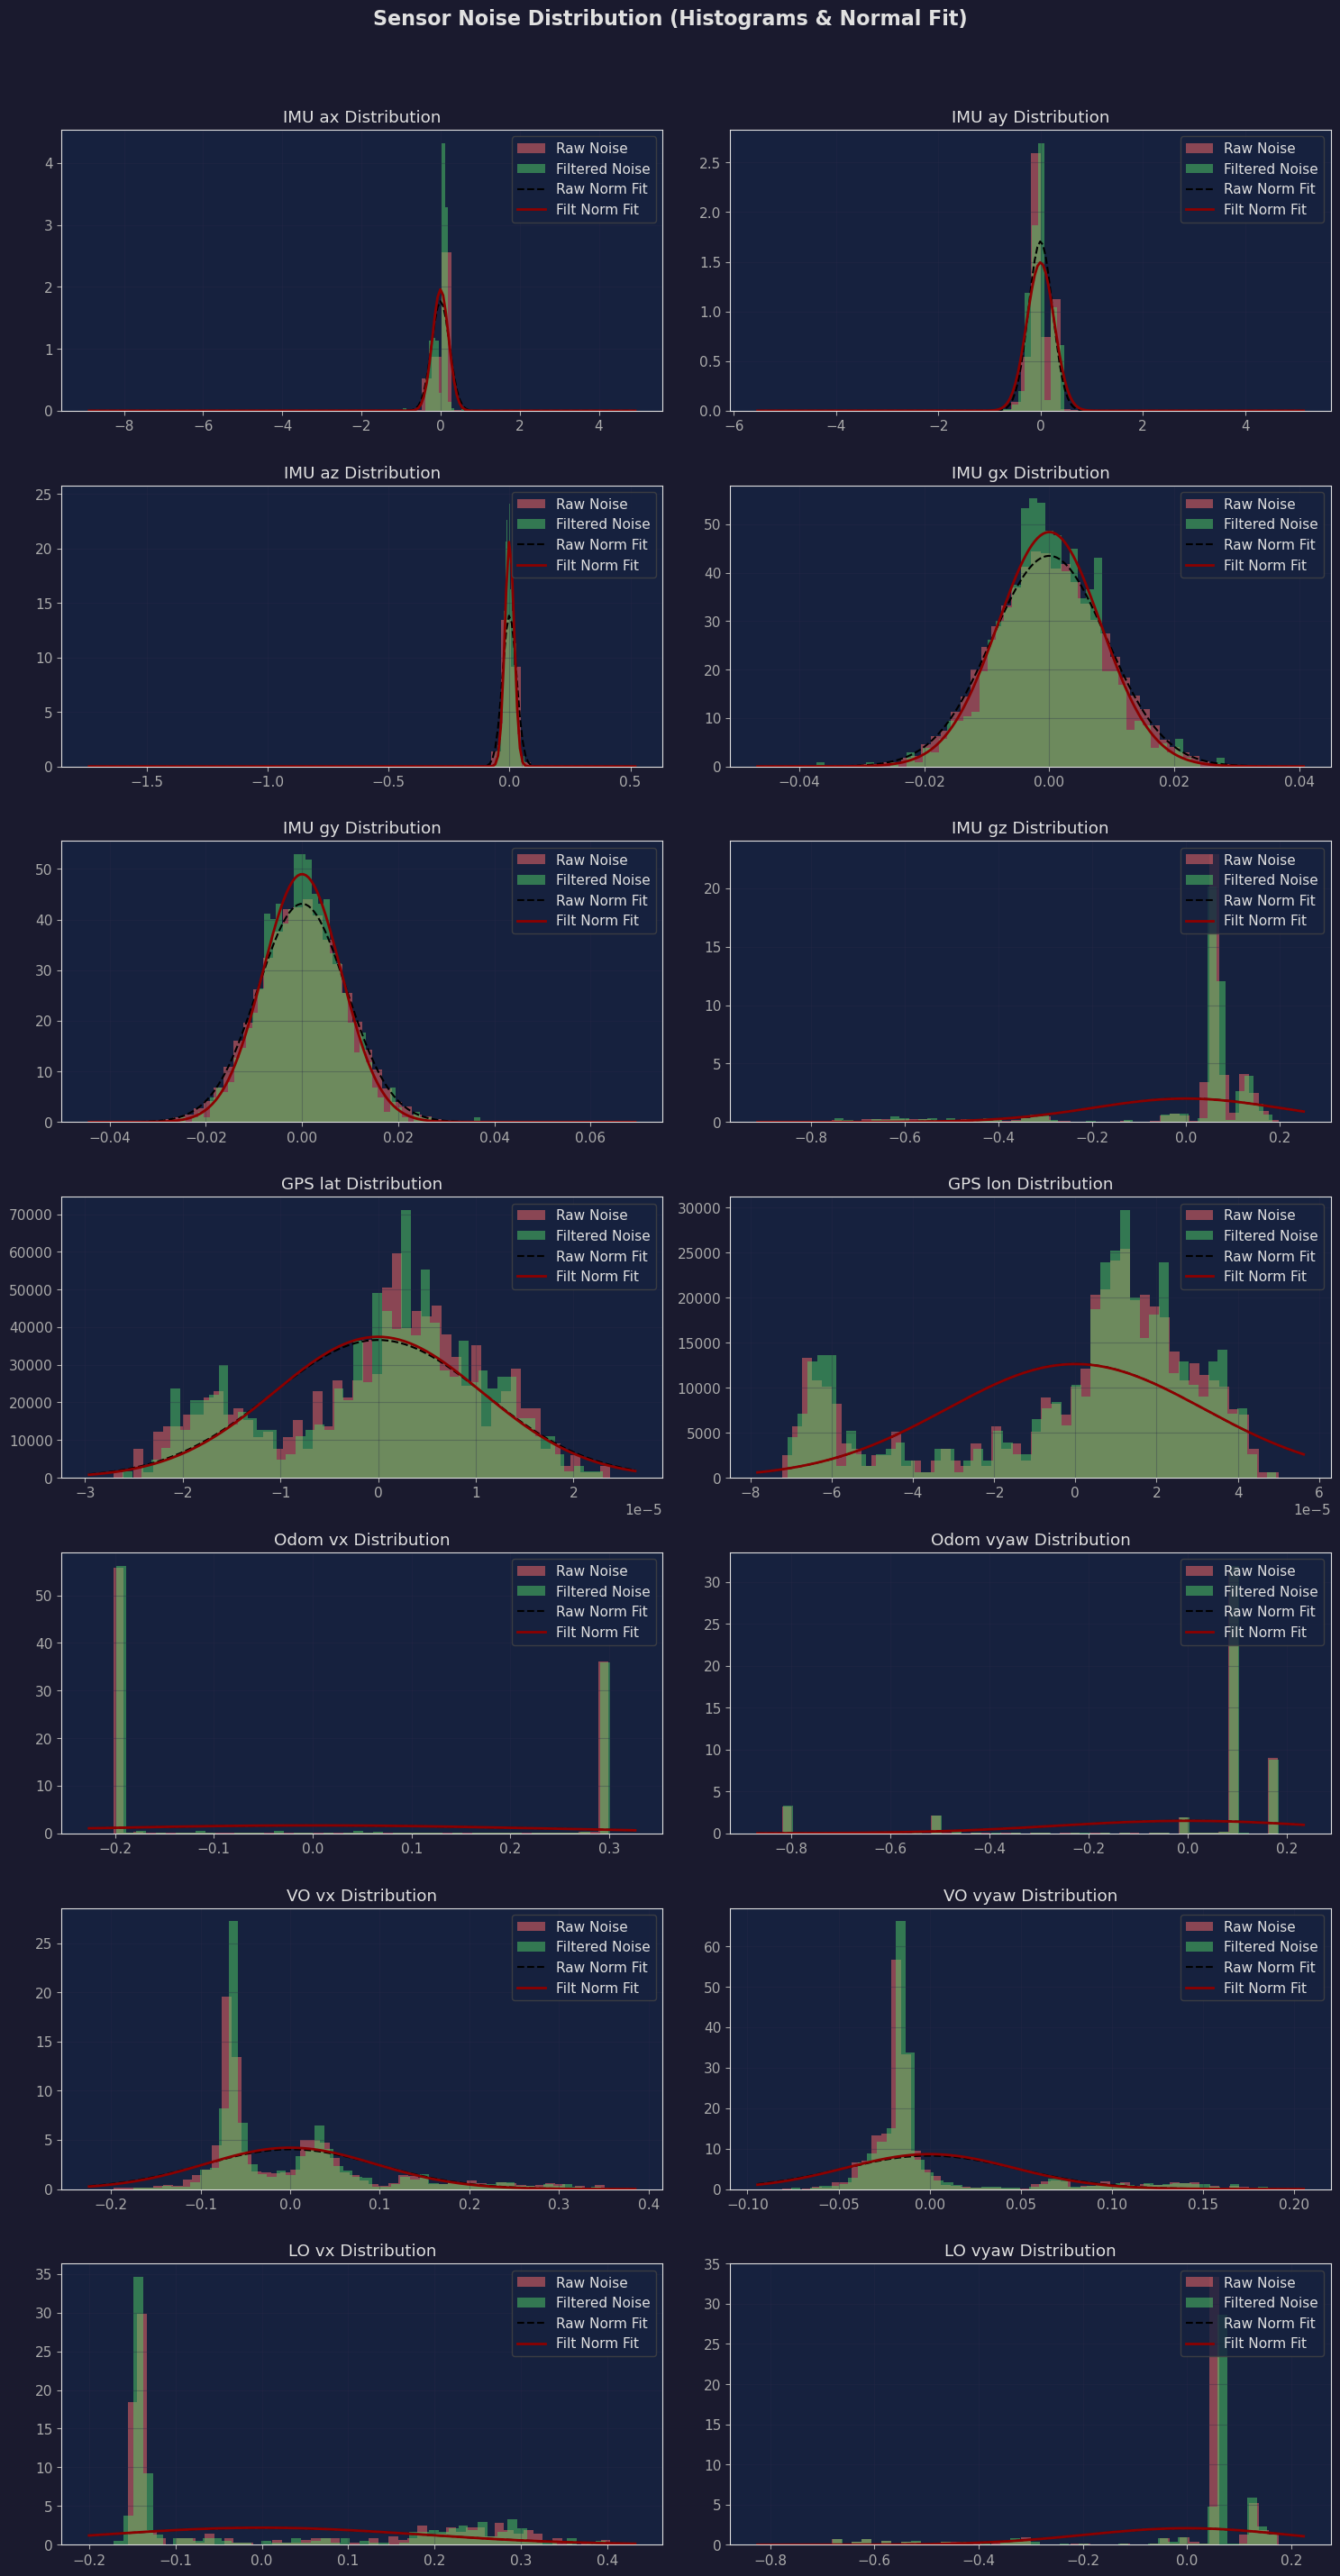


Saved: plots/qf_noise_distributions.png


In [9]:
import scipy.stats as stats
import math

sensors = [
    ('IMU ax', 'imu_raw', 'imu_filt', 'ax'),
    ('IMU ay', 'imu_raw', 'imu_filt', 'ay'),
    ('IMU az', 'imu_raw', 'imu_filt', 'az'),
    ('IMU gx', 'imu_raw', 'imu_filt', 'gx'),
    ('IMU gy', 'imu_raw', 'imu_filt', 'gy'),
    ('IMU gz', 'imu_raw', 'imu_filt', 'gz'),
    ('GPS lat', 'gps_raw', 'gps_filt', 'lat'),
    ('GPS lon', 'gps_raw', 'gps_filt', 'lon'),
    ('Odom vx', 'odom_raw', 'odom_filt', 'vx'),
    ('Odom vyaw', 'odom_raw', 'odom_filt', 'vyaw'),
    ('VO vx', 'vo_raw', 'vo_filt', 'vx'),
    ('VO vyaw', 'vo_raw', 'vo_filt', 'vyaw'),
    ('LO vx', 'lo_raw', 'lo_filt', 'vx'),
    ('LO vyaw', 'lo_raw', 'lo_filt', 'vyaw')
]

valid_sensors = [s for s in sensors if s[1] in dfs and s[2] in dfs]

if valid_sensors:
    n = len(valid_sensors)
    cols = 2
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    axes = axes.flatten() if n > 1 else [axes]
    fig.suptitle('Sensor Noise Distribution (Histograms & Normal Fit)', fontsize=16, fontweight='bold', y=1.02)

    print(f"{'Sensor':<12} | {'Raw Var':<12} | {'Filt Var':<12} | {'Raw Std':<12} | {'Filt Std':<12} | {'% Red.':<8}")
    print("-"*82)

    for i, (name, raw_key, filt_key, ch) in enumerate(valid_sensors):
        raw_data = npcol(dfs[raw_key], ch)
        filt_data = npcol(dfs[filt_key], ch)

        # Remove NaNs
        raw_data = raw_data[~np.isnan(raw_data)]
        filt_data = filt_data[~np.isnan(filt_data)]

        if len(raw_data) == 0 or len(filt_data) == 0:
            continue

        raw_var, filt_var = np.var(raw_data), np.var(filt_data)
        raw_std, filt_std = np.std(raw_data), np.std(filt_data)
        reduction = (1 - filt_std / raw_std) * 100 if raw_std > 0 else 0

        print(f"{name:<12} | {raw_var:<12.6f} | {filt_var:<12.6f} | {raw_std:<12.6f} | {filt_std:<12.6f} | {reduction:<8.2f}%")

        # Mean subtraction to center the noise around 0
        raw_noise = raw_data - np.mean(raw_data)
        filt_noise = filt_data - np.mean(filt_data)

        # Plot histograms
        axes[i].hist(raw_noise, bins=50, density=True, alpha=0.5, color=COLORS.get('raw', '#34495e'), label='Raw Noise')
        axes[i].hist(filt_noise, bins=50, density=True, alpha=0.5, color=COLORS.get('filtered', '#2ecc71'), label='Filtered Noise')
        
        # Fit normal distribution to overlay
        xmin, xmax = axes[i].get_xlim()
        x = np.linspace(xmin, xmax, 200)
        axes[i].plot(x, stats.norm.pdf(x, 0, raw_std), color='black', linestyle='dashed', lw=1.5, label='Raw Norm Fit')
        axes[i].plot(x, stats.norm.pdf(x, 0, filt_std), color='darkred', linestyle='solid', lw=2, label='Filt Norm Fit')

        axes[i].set_title(f"{name} Distribution")
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_noise_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved: plots/qf_noise_distributions.png')
else:
    print('⚠ No sensor data found for noise analytics.')


## 5. XY Trajectory: Raw Odom → QF-Odom → EKF Local → EKF Global

Compare the full pipeline trajectory at each stage.

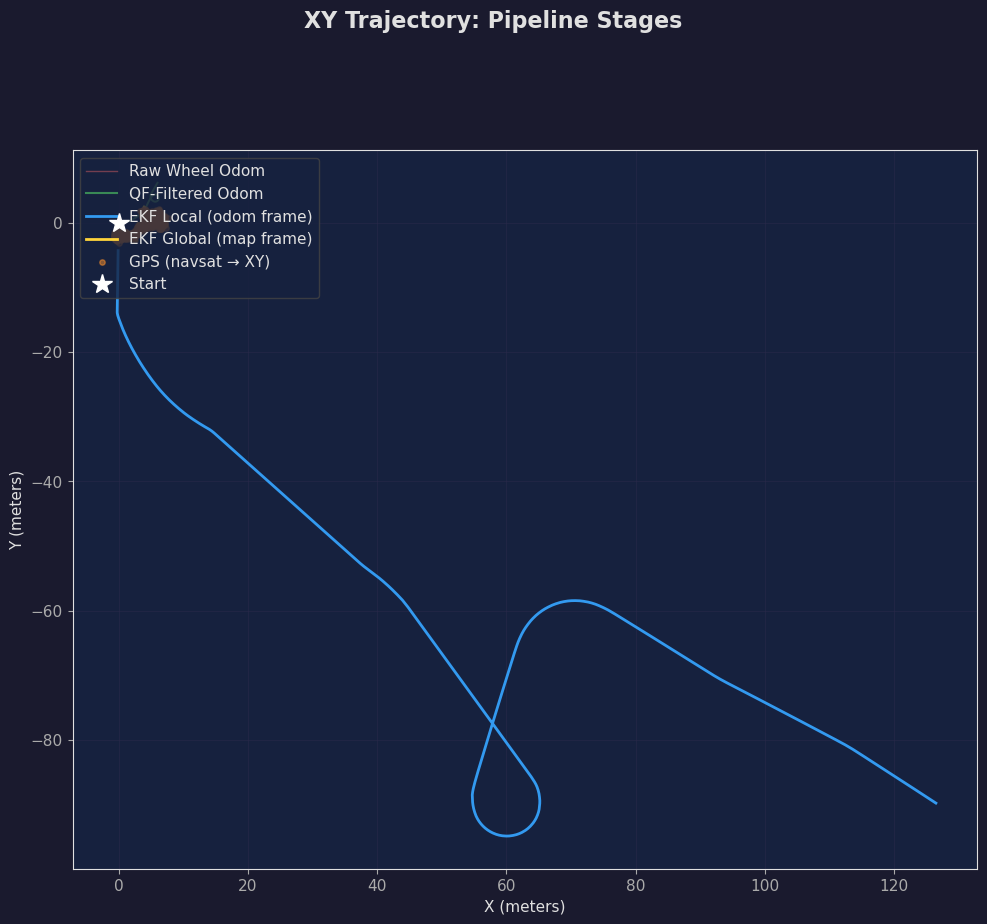

Saved: plots/qf_ekf_trajectory.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle('XY Trajectory: Pipeline Stages', fontsize=16, fontweight='bold')

if 'odom_raw' in dfs:
    x, y = npxy(dfs['odom_raw'])
    ax.plot(x, y, color=COLORS['raw'], alpha=0.4, lw=1, label='Raw Wheel Odom')

if 'odom_filt' in dfs:
    x, y = npxy(dfs['odom_filt'])
    ax.plot(x, y, color=COLORS['filtered'], alpha=0.6, lw=1.5, label='QF-Filtered Odom')

if 'ekf_local' in dfs:
    x, y = npxy(dfs['ekf_local'])
    ax.plot(x, y, color=COLORS['ekf_local'], lw=2, label='EKF Local (odom frame)')

if 'ekf_global' in dfs:
    x, y = npxy(dfs['ekf_global'])
    ax.plot(x, y, color=COLORS['ekf_global'], lw=2, label='EKF Global (map frame)')

if 'gps_odom' in dfs:
    x, y = npxy(dfs['gps_odom'])
    ax.scatter(x, y, color=COLORS['gps'], s=15, alpha=0.5, zorder=5, label='GPS (navsat → XY)')

ax.plot(0, 0, 'w*', markersize=15, zorder=10, label='Start')
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/qf_ekf_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/qf_ekf_trajectory.png')

## 6. Drift Analysis: EKF Local vs EKF Global

Quantify how much the local estimate drifts from the GPS-corrected global estimate over time.


── QF+EKF Drift Summary ──
  Duration:   67.4 s
  Final drift: 152.7033 m
  Max drift:   152.7033 m
  Mean drift:  65.0247 m
  Drift rate:  136.0220 m/min


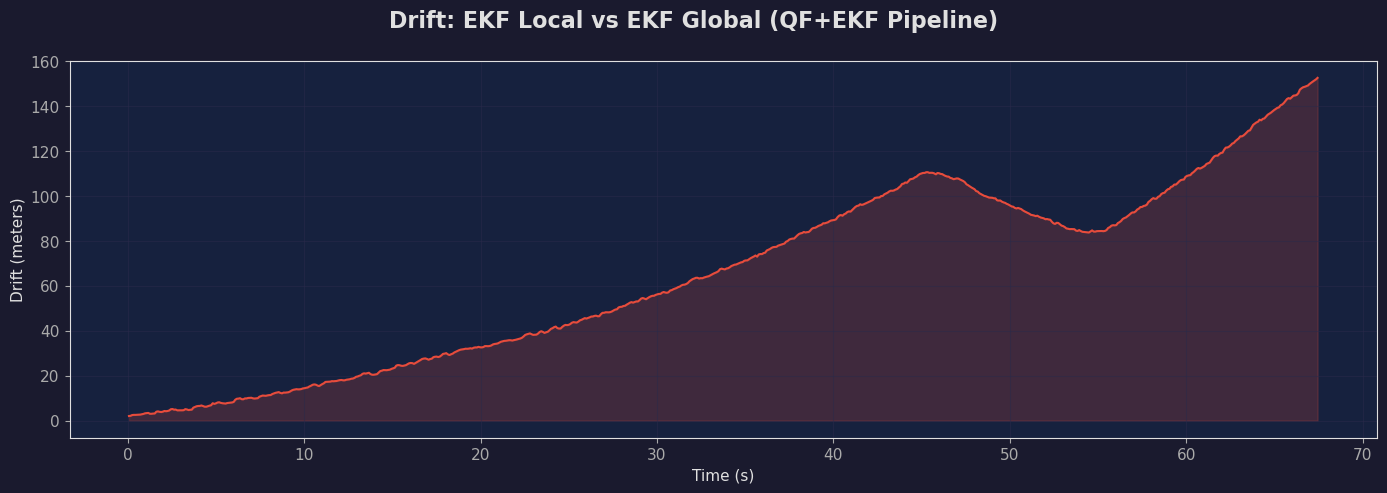

Saved: plots/qf_ekf_drift.png


In [11]:
if 'ekf_local' in dfs and 'ekf_global' in dfs:
    local = dfs['ekf_local'].copy()
    glob_ = dfs['ekf_global'].copy()

    # Interpolate onto common time axis
    t_local = npcol(local, 't')
    t_glob = npcol(glob_, 't')
    t_min = max(t_local[0], t_glob[0])
    t_max = min(t_local[-1], t_glob[-1])
    t_common = np.linspace(t_min, t_max, min(len(t_local), len(t_glob)))

    lx = np.interp(t_common, t_local, npcol(local, 'x'))
    ly = np.interp(t_common, t_local, npcol(local, 'y'))
    gx = np.interp(t_common, t_glob, npcol(glob_, 'x'))
    gy = np.interp(t_common, t_glob, npcol(glob_, 'y'))

    drift = np.sqrt((lx - gx)**2 + (ly - gy)**2)

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle('Drift: EKF Local vs EKF Global (QF+EKF Pipeline)',
                 fontsize=16, fontweight='bold')
    ax.plot(t_common, drift, color='#e74c3c', lw=1.5)
    ax.fill_between(t_common, 0, drift, alpha=0.2, color='#e74c3c')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Drift (meters)')
    ax.grid(True)

    duration = t_common[-1] - t_common[0]
    print(f'\n── QF+EKF Drift Summary ──')
    print(f'  Duration:   {duration:.1f} s')
    print(f'  Final drift: {drift[-1]:.4f} m')
    print(f'  Max drift:   {drift.max():.4f} m')
    print(f'  Mean drift:  {drift.mean():.4f} m')
    print(f'  Drift rate:  {drift[-1] / (duration / 60):.4f} m/min')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/qf_ekf_drift.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/qf_ekf_drift.png')
else:
    print('⚠ EKF local/global data not found in bag')

## 7. Summary: Noise Reduction & Pipeline Quality

In [12]:
print('╔' + '═' * 70 + '╗')
print('║  QUANTUM FILTER + EKF ANALYSIS SUMMARY'.ljust(71) + '║')
print('╠' + '═' * 70 + '╣')

# IMU noise reduction
if 'imu_raw' in dfs and 'imu_filt' in dfs:
    raw, filt = dfs['imu_raw'], dfs['imu_filt']
    reductions = []
    for ch in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        r = np.nanstd(npcol(raw, ch))
        f = np.nanstd(npcol(filt, ch))
        reductions.append((1 - f/r) * 100 if r > 0 else 0)
    avg_imu = np.mean(reductions)
    print(f'║  IMU noise reduction (avg):     {avg_imu:6.1f}%'.ljust(71) + '║')

# GPS noise reduction
if 'gps_raw' in dfs and 'gps_filt' in dfs:
    raw, filt = dfs['gps_raw'], dfs['gps_filt']
    reductions = []
    for ch in ['lat', 'lon']:
        r = np.nanstd(npcol(raw, ch))
        f = np.nanstd(npcol(filt, ch))
        reductions.append((1 - f/r) * 100 if r > 0 else 0)
    avg_gps = np.mean(reductions)
    print(f'║  GPS noise reduction (avg):     {avg_gps:6.1f}%'.ljust(71) + '║')

# Odom noise reduction
if 'odom_raw' in dfs and 'odom_filt' in dfs:
    raw, filt = dfs['odom_raw'], dfs['odom_filt']
    reductions = []
    for ch in ['vx', 'vyaw']:
        r = np.nanstd(npcol(raw, ch))
        f = np.nanstd(npcol(filt, ch))
        reductions.append((1 - f/r) * 100 if r > 0 else 0)
    avg_odom = np.mean(reductions)
    print(f'║  Odom noise reduction (avg):    {avg_odom:6.1f}%'.ljust(71) + '║')

# VO noise reduction
if 'vo_raw' in dfs and 'vo_filt' in dfs:
    raw, filt = dfs['vo_raw'], dfs['vo_filt']
    reductions = []
    for ch in ['vx', 'vyaw']:
        r = np.nanstd(npcol(raw, ch))
        f = np.nanstd(npcol(filt, ch))
        reductions.append((1 - f/r) * 100 if r > 0 else 0)
    avg_vo = np.mean(reductions)
    print(f'║  Visual Odom noise reduction:   {avg_vo:6.1f}%'.ljust(71) + '║')

# LO noise reduction
if 'lo_raw' in dfs and 'lo_filt' in dfs:
    raw, filt = dfs['lo_raw'], dfs['lo_filt']
    reductions = []
    for ch in ['vx', 'vyaw']:
        r = np.nanstd(npcol(raw, ch))
        f = np.nanstd(npcol(filt, ch))
        reductions.append((1 - f/r) * 100 if r > 0 else 0)
    avg_lo = np.mean(reductions)
    print(f'║  LiDAR Odom noise reduction:    {avg_lo:6.1f}%'.ljust(71) + '║')

# Drift
if 'ekf_local' in dfs and 'ekf_global' in dfs:
    print(f'║  EKF drift (final):             {drift[-1]:6.4f} m'.ljust(71) + '║')
    print(f'║  EKF drift (max):               {drift.max():6.4f} m'.ljust(71) + '║')
    print(f'║  EKF drift rate:                {drift[-1]/(duration/60):6.4f} m/min'.ljust(71) + '║')

print('╚' + '═' * 70 + '╝')

╔══════════════════════════════════════════════════════════════════════╗
║  QUANTUM FILTER + EKF ANALYSIS SUMMARY                               ║
╠══════════════════════════════════════════════════════════════════════╣
║  IMU noise reduction (avg):        8.4%                              ║
║  GPS noise reduction (avg):        1.1%                              ║
║  Odom noise reduction (avg):      -0.3%                              ║
║  Visual Odom noise reduction:      4.2%                              ║
║  LiDAR Odom noise reduction:       0.5%                              ║
║  EKF drift (final):             152.7033 m                           ║
║  EKF drift (max):               152.7033 m                           ║
║  EKF drift rate:                136.0220 m/min                       ║
╚══════════════════════════════════════════════════════════════════════╝
